# MDAT IRT–VAE Scoring

This notebook converts raw **MDAT (Malawi Developmental Assessment Tool)** item responses into latent ability scores for five domains — social (`s`), fine motor (`fm`), gross motor (`gm`), language (`l`), and total (`tot`) — using an IRT-constrained Variational Autoencoder (IRT–VAE).

## What this notebook does

1. Loads the raw MDAT response CSV and filters by age.
2. For each domain (and a combined total), selects the relevant item columns and builds a binary response matrix `Y` and observation mask `M`.
3. Trains an **Encoder–Decoder VAE** where the decoder follows the **2-Parameter Logistic (2PL) IRT** model: `P(Y=1 | θ) = σ(a·θ − b)`. The encoder is an MLP mapping `[Y, M, age]` → `(μ, logvar)`.
4. Scores all children using the encoder posterior mean `μ` as the latent ability `θ`.
5. Combines domain scores into a single output CSV.

## Inputs required

| File | Description |
|---|---|
| `mdat_data.csv` | Raw MDAT responses. Columns: metadata fields + item columns prefixed by domain (`s1`…`sN`, `fm1`…, `gm1`…, `l1`…). Responses coded as `1` (pass), `-1` (fail), `0` / NaN (not administered). |

## Outputs produced

| File | Description |
|---|---|
| `age_{domain}_Deep_ability_0.csv` | Per-domain latent scores (one file per domain) |
| `mdat_Deep_abilities_0.csv` | Combined scores: `child_ids`, `Age`, `s`, `fm`, `gm`, `l`, `tot` |

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset

DATA_PATH = "mdat_data.csv"
AGE_MIN_DAYS = 0 

SCORING_RUNS = {
    "s": {
        "prefixes": ("s",),
        "output_prefix": "age_s_Deep_ability",
    },
    "fm": {
        "prefixes": ("fm",),
        "output_prefix": "age_fm_Deep_ability",
    },
    "gm": {
        "prefixes": ("gm",),
        "output_prefix": "age_gm_Deep_ability",
    },
    "l": {
        "prefixes": ("l",),
        "output_prefix": "age_l_Deep_ability",
    },
    "tot": {
        "prefixes": ("s", "fm", "gm", "l"),
        "output_prefix": "age_tot_Deep_ability",
    },
}

COMBINED_OUTPUT_PREFIX = "mdat_Deep_abilities"
METADATA_COLUMNS = ["child_ids", "DOBs", "Sex", "Age", "Country", "Component", "ID"]

LATENT_DIM = 1
EPOCHS = 200
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
TEST_SIZE = 0.01
RANDOM_STATE = 42
SHOW_PLOTS = True


## Data Preparation

`prepare_mdat_inputs` handles all pre-processing for a single domain run:
- Filters children by `AGE_MIN_DAYS`.
- Selects item columns matching the domain prefix(es).
- Converts raw codes (`1` → pass, `-1` → fail, `0`/NaN → unobserved) into a binary response matrix `Y` and a float observation mask `M` (1 = observed, 0 = missing).
- Missing items are **excluded from the reconstruction loss** via the mask; they do not need to be imputed.

`select_domain_columns` sorts item columns by their numeric suffix so the item order is deterministic across runs.

In [28]:
def sort_domain_columns(columns, prefix):
    def sort_key(column_name):
        suffix = column_name[len(prefix):]
        return int(suffix) if suffix.isdigit() else suffix

    return sorted(columns, key=sort_key)


def select_domain_columns(feature_data, prefixes):
    selected_cols = []
    seen = set()

    for prefix in prefixes:
        prefix_cols = sort_domain_columns(
            [col for col in feature_data.columns if col.startswith(prefix)],
            prefix,
        )
        for col in prefix_cols:
            if col not in seen:
                selected_cols.append(col)
                seen.add(col)

    if not selected_cols:
        raise ValueError(f"No columns matched prefixes {prefixes}.")

    return selected_cols


def format_age_tag(age_min_days):
    return f"{age_min_days:g}"


def build_output_filename(prefix, age_min_days=AGE_MIN_DAYS):
    return f"{prefix}_{format_age_tag(age_min_days)}.csv"


def prepare_mdat_inputs(dataframe, prefixes, age_min_days=AGE_MIN_DAYS, verbose=True):
    filtered_data = dataframe.loc[dataframe["Age"] > age_min_days].copy().reset_index(drop=True)
    if filtered_data.empty:
        raise ValueError(f"No rows found with Age > {age_min_days:g} days.")

    row_id = filtered_data.index.to_numpy()
    ids = filtered_data["child_ids"].astype(str).to_numpy()
    ages_days = filtered_data["Age"].to_numpy(dtype=np.float32)
    ages_years = ages_days / 365.0

    feature_data = filtered_data.drop(
        columns=[col for col in METADATA_COLUMNS if col in filtered_data.columns]
    )
    selected_cols = select_domain_columns(feature_data, prefixes)
    domain_data = feature_data[selected_cols]

    raw = domain_data.to_numpy()
    Y = np.zeros_like(raw, dtype=np.float32)
    M = np.zeros_like(raw, dtype=np.float32)

    Y[raw == 1] = 1.0
    Y[raw == -1] = 0.0
    M[raw != 0] = 1.0

    if verbose:
        print(f"Selected columns for {prefixes}: {selected_cols}")

    return {
        "filtered_data": filtered_data,
        "row_id": row_id,
        "ids": ids,
        "ages_days": ages_days,
        "ages_years": ages_years,
        "feature_data": domain_data,
        "selected_cols": selected_cols,
        "Y": Y,
        "M": M,
    }


In [29]:
class StudentDataset(Dataset):
    """Dataset wrapper for binary responses, observation masks, and normalized age."""

    def __init__(self, Y, M, age):
        self.Y = torch.tensor(Y, dtype=torch.float32)
        self.M = torch.tensor(M, dtype=torch.float32)
        self.age = torch.tensor(age, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return self.Y.shape[0]

    def __getitem__(self, idx):
        return self.Y[idx], self.M[idx], self.age[idx]


## Model Architecture

### Encoder
An MLP that maps `[Y, M, age_normalised]` (concatenated) to the VAE posterior parameters `(μ, logvar)`. Inputs are concatenated so the encoder can learn to up-weight observed items and ignore masked positions. An auxiliary linear head predicts age from `μ` — this head is used for monitoring only (weights `gamma=0`, `delta=0` in the loss); it can be enabled to softly encourage the latent space to align with age.

### Decoder — 2PL IRT
The decoder is **not** a neural network. It implements the 2-Parameter Logistic IRT model:

```
P(Y_ij = 1 | θ_i) = σ(a_j · θ_i − b_j)
```

where `a_j` is the item discrimination, `b_j` is the item difficulty, and `θ_i = μ_i` is the latent ability. Both `a` and `b` are learnable parameters, giving the VAE the same parametric structure as classical IRT while using the encoder to infer abilities from patterns in the response data.

In [30]:
class Encoder(nn.Module):
    def __init__(self, input_dim=315, hidden_dims=[64, 32], latent_dim=4, dropout=0.2):
        super().__init__()

        dims = [input_dim] + hidden_dims
        self.mlp = nn.ModuleList([
            nn.Linear(dims[i], dims[i + 1]) for i in range(len(dims) - 1)
        ])

        self.fc_mu = nn.Linear(hidden_dims[-1], latent_dim)
        self.age_predictor = nn.Linear(latent_dim, 1)
        self.fc_logvar = nn.Linear(hidden_dims[-1], latent_dim)

    def forward(self, y, m, age):
        x = torch.cat([y, m, age], dim=-1)
        for layer in self.mlp:
            x = torch.tanh(layer(x))
        mu = self.fc_mu(x)
        age_hat = self.age_predictor(mu)
        logvar = self.fc_logvar(x)
        return mu, logvar, age_hat


class Decoder(nn.Module):
    def __init__(self, num_items, latent_dim):
        super().__init__()
        self.a = nn.Parameter(torch.randn(num_items, latent_dim))
        self.b = nn.Parameter(torch.randn(num_items))

    def forward(self, theta):
        logits = torch.matmul(theta, self.a.T) - self.b
        return torch.sigmoid(logits)


## Loss Functions

The training objective is the **Evidence Lower BOund (ELBO)**:

```
ELBO = E[log p(Y | θ)] − β · KL(q(θ|Y) ‖ p(θ))
       + γ · MSE(age_hat, age)
       + δ · uniformity_penalty(age_predictor.weight)
```

- **Reconstruction** (`masked_bce_loss`): Binary cross-entropy summed only over observed entries (mask = 1), normalised by the total count of observed responses.
- **KL divergence**: Analytical KL between the encoder's Gaussian posterior `q(θ|Y) = N(μ, exp(logvar))` and the prior `p(θ) = N(0,1)`.
- **Age loss** (optional, γ=0 by default): MSE between the predicted age from the latent head and the true normalised age. Setting γ > 0 explicitly encourages the latent dimension to track age.
- **Uniformity penalty** (optional, δ=0 by default): Penalises variance in the age-predictor weights, encouraging them to load uniformly across latent dimensions.

`β=1.0` in MDAT (standard VAE). The deterministic scoring uses `θ = μ` (no sampling at inference time).

In [31]:
def deterministic_theta(mu, logvar=None):
    """Keep the latent ability deterministic by using the encoder mean."""
    return mu


def kl_divergence(mu, logvar):
    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    return kl.sum(dim=1).mean()


def age_weight_uniformity_loss(weight, lambda_var=1.0, lambda_neg=1.0):
    w = weight.view(-1)
    mean = torch.mean(w)
    variance_penalty = torch.sum((w - mean) ** 2)
    negativity_penalty = torch.sum(F.relu(-w))
    return lambda_var * variance_penalty + lambda_neg * negativity_penalty


def masked_bce_loss(pred_probs, target, mask):
    bce = F.binary_cross_entropy(pred_probs, target, reduction="none")
    masked_bce = bce * mask
    return masked_bce.sum() / mask.sum()


def elbo_loss(
    mu,
    logvar,
    pred_probs,
    y,
    m,
    age_hat,
    age_tensor,
    encoder,
    beta=0.1,
    gamma=1.0,
    delta=1.0,
):
    recon = masked_bce_loss(pred_probs, y, m)
    kl = kl_divergence(mu, logvar)
    age_loss = F.mse_loss(age_hat.view(-1), age_tensor.view(-1))
    age_uniformity_penalty = age_weight_uniformity_loss(encoder.age_predictor.weight)
    total_loss = recon + beta * kl + gamma * age_loss + delta * age_uniformity_penalty
    return total_loss, recon, kl, age_loss


## Training and Scoring

`train_and_score_configuration` runs the full train–evaluate–score pipeline for one domain:

1. **Split**: Stratified random split into train (99%) / test (1%). The 1% test set is used only for a held-out reconstruction accuracy metric; it does not affect training.
2. **Age normalisation**: Ages are normalised to zero mean and unit variance using train-set statistics. All children (including test) are normalised with those same statistics for scoring.
3. **Training loop**: Adam optimiser, gradient descent on ELBO. Early stopping on NaN loss.
4. **Evaluation**: Masked BCE loss and per-item reconstruction accuracy on the test set.
5. **Scoring all children**: The encoder mean `μ[:,0]` is used as the ability estimate `θ`. If the raw correlation with age is negative, the sign is flipped (ensuring higher score = better development).
6. **Output**: A `score_df` with `child_ids`, `Age`, and `Ability` columns, plus a scatter plot of ability vs age.

The function is called once per domain entry in `SCORING_RUNS`.

In [32]:
def train_and_score_configuration(raw_data, run_key, config, age_min_days=AGE_MIN_DAYS, show_plots=SHOW_PLOTS):
    run_inputs = prepare_mdat_inputs(
        raw_data,
        prefixes=config["prefixes"],
        age_min_days=age_min_days,
        verbose=False,
    )

    Y = run_inputs["Y"]
    M = run_inputs["M"]
    ages_days = run_inputs["ages_days"]
    ages_years = run_inputs["ages_years"]

    print(f"\n=== Running {run_key} | age > {age_min_days:g} days ===")
    print(f"Selected {len(run_inputs['selected_cols'])} columns")

    train_idx, test_idx = train_test_split(
        np.arange(len(Y)),
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        shuffle=True,
    )

    Y_train, Y_test = Y[train_idx], Y[test_idx]
    M_train, M_test = M[train_idx], M[test_idx]
    ages_train_days, ages_test_days = ages_days[train_idx], ages_days[test_idx]

    age_mean = ages_train_days.mean()
    age_std = ages_train_days.std()
    if age_std == 0:
        raise ValueError("Training ages have zero variance; cannot normalize ages.")

    ages_train = ((ages_train_days - age_mean) / age_std).astype(np.float32)
    ages_test = ((ages_test_days - age_mean) / age_std).astype(np.float32)
    ages_norm_full = ((ages_days - age_mean) / age_std).astype(np.float32)

    print(f"Train size: {Y_train.shape[0]}, Test size: {Y_test.shape[0]}")
    print(f"Items: {Y.shape[1]}")
    print(f"Age normalization mean: {age_mean:.2f}, std: {age_std:.2f}")

    torch.manual_seed(RANDOM_STATE)
    num_items = Y.shape[1]
    encoder = Encoder(input_dim=2 * num_items + 1, latent_dim=LATENT_DIM)
    decoder = Decoder(num_items=num_items, latent_dim=LATENT_DIM)

    params = list(encoder.parameters()) + list(decoder.parameters())
    optimizer = Adam(params, lr=LEARNING_RATE)

    dataset = StudentDataset(Y_train, M_train, ages_train)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    beta = 1.0
    gamma = 0.0
    delta = 0.0

    for epoch in range(EPOCHS):
        encoder.train()
        decoder.train()
        total_loss, total_recon, total_kl, total_age_loss = 0.0, 0.0, 0.0, 0.0

        for y_batch, m_batch, age_batch in loader:
            optimizer.zero_grad()

            mu, logvar, age_hat = encoder(y_batch, m_batch, age_batch)
            theta = deterministic_theta(mu, logvar)
            pred_probs = decoder(theta)

            loss, recon, kl, age_loss = elbo_loss(
                mu,
                logvar,
                pred_probs,
                y_batch,
                m_batch,
                age_hat=age_hat,
                age_tensor=age_batch,
                encoder=encoder,
                beta=beta,
                gamma=gamma,
                delta=delta,
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()
            total_age_loss += age_loss.item()

        print(
            f"Epoch {epoch + 1:03d} | Total Loss: {total_loss:.2f} | "
            f"Recon: {total_recon:.2f} | KL: {total_kl:.2f} | Age monitor: {total_age_loss:.2f}"
        )

    Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)
    M_test_tensor = torch.tensor(M_test, dtype=torch.float32)
    ages_test_tensor = torch.tensor(ages_test, dtype=torch.float32).unsqueeze(1)

    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        mu_test, _, _ = encoder(Y_test_tensor, M_test_tensor, ages_test_tensor)
        theta_test = deterministic_theta(mu_test)
        pred_probs = decoder(theta_test)

        recon_loss = F.binary_cross_entropy(pred_probs, Y_test_tensor, reduction="none")
        masked_loss = recon_loss * M_test_tensor
        total_loss = masked_loss.sum().item()
        total_known = M_test_tensor.sum().item()
        avg_loss = total_loss / total_known

        pred_labels = (pred_probs > 0.5).float()
        correct = ((pred_labels == Y_test_tensor) * M_test_tensor).sum().item()
        accuracy = correct / total_known

        accs = []
        for j in range(Y_test_tensor.shape[1]):
            m_j = M_test_tensor[:, j]
            if m_j.sum() == 0:
                continue
            y_j = Y_test_tensor[:, j]
            p_j = pred_labels[:, j]
            acc = ((p_j == y_j) * m_j).sum() / m_j.sum()
            accs.append(acc.item())

    print(f"Total recon loss: {total_loss:.2f}")
    print(f"Avg recon loss per observed response: {avg_loss:.6f}")
    print(f"Observed-response reconstruction accuracy: {accuracy * 100:.2f}%")

    Y_tensor = torch.tensor(Y, dtype=torch.float32)
    M_tensor = torch.tensor(M, dtype=torch.float32)
    ages_tensor = torch.tensor(ages_norm_full, dtype=torch.float32).unsqueeze(1)

    with torch.no_grad():
        mu_all, _, _ = encoder(Y_tensor, M_tensor, ages_tensor)
        theta_all = deterministic_theta(mu_all)[:, 0].detach().cpu().numpy()

    if len(theta_all) > 1:
        corr = np.corrcoef(theta_all, ages_years)[0, 1]
        if not np.isnan(corr) and corr < 0:
            theta_all = -theta_all

    score_df = pd.DataFrame(
        {
            "row_id": run_inputs["row_id"],
            "child_ids": run_inputs["ids"],
            "Age": ages_days,
            "Ability": theta_all,
        }
    )
    output_path = build_output_filename(config["output_prefix"], age_min_days)
    # score_df.to_csv(output_path, index=False)
    print(f"Saved {output_path}")

    if show_plots:
        plt.figure(figsize=(8, 4))
        plt.hist(accs, bins=30)
        plt.xlabel("Item-wise Accuracy")
        plt.ylabel("Number of Items")
        plt.title(f"Observed-response Reconstruction Accuracy per Item: {run_key}")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10, 6))
        plt.scatter(ages_years, theta_all, alpha=0.6, s=15)
        plt.xlabel("Age (years)")
        plt.ylabel("Latent Ability (theta)")
        plt.title(f"Estimated Ability vs Age: {run_key}")
        plt.grid(True)
        plt.show()

    return {
        "run_key": run_key,
        "output_path": output_path,
        "score_df": score_df,
        "selected_cols": run_inputs["selected_cols"],
        "train_size": int(Y_train.shape[0]),
        "test_size": int(Y_test.shape[0]),
        "num_items": int(num_items),
        "avg_loss": float(avg_loss),
        "accuracy": float(accuracy),
    }


## Combining Domain Scores

`combine_scoring_outputs` merges the five domain score DataFrames on `child_ids` (inner join), retaining only children who were scored in all five runs. The combined CSV has columns: `child_ids`, `Age`, `s`, `fm`, `gm`, `l`, `tot`.

In [33]:
def combine_scoring_outputs(run_outputs, age_min_days=AGE_MIN_DAYS):
    merge_keys = ["row_id", "child_ids", "Age"]

    s_df = run_outputs["s"]["score_df"].rename(columns={"Ability": "s"})
    fm_df = run_outputs["fm"]["score_df"].rename(columns={"Ability": "fm"})
    gm_df = run_outputs["gm"]["score_df"].rename(columns={"Ability": "gm"})
    l_df = run_outputs["l"]["score_df"].rename(columns={"Ability": "l"})
    tot_df = run_outputs["tot"]["score_df"].rename(columns={"Ability": "tot"})

    combined_scores = (
        s_df
        .merge(fm_df[merge_keys + ["fm"]], on=merge_keys, how="inner")
        .merge(gm_df[merge_keys + ["gm"]], on=merge_keys, how="inner")
        .merge(l_df[merge_keys + ["l"]], on=merge_keys, how="inner")
        .merge(tot_df[merge_keys + ["tot"]], on=merge_keys, how="inner")
    )

    combined_scores = combined_scores[["child_ids", "Age", "s", "fm", "gm", "l", "tot"]]
    combined_output_path = build_output_filename(COMBINED_OUTPUT_PREFIX, age_min_days)
    combined_scores.to_csv(combined_output_path, index=False)
    print(f"Saved {combined_output_path}")

    return combined_scores, combined_output_path


## Run All Domains

The cell below iterates over all five entries in `SCORING_RUNS`, trains one IRT–VAE per domain, and collects the results. Training 5 models × 200 epochs takes approximately 5–10 minutes on a CPU. Set `SHOW_PLOTS = False` to suppress intermediate figures and speed up execution.


=== Running s | age > 0 days ===
Selected 36 columns
Train size: 1947, Test size: 20
Items: 36
Age normalization mean: 549.53, std: 311.63
Epoch 001 | Total Loss: 49.31 | Recon: 49.04 | KL: 0.27 | Age monitor: 62.64
Epoch 002 | Total Loss: 48.14 | Recon: 47.82 | KL: 0.32 | Age monitor: 62.42
Epoch 003 | Total Loss: 47.13 | Recon: 46.72 | KL: 0.40 | Age monitor: 62.17
Epoch 004 | Total Loss: 46.12 | Recon: 45.63 | KL: 0.49 | Age monitor: 61.82
Epoch 005 | Total Loss: 45.12 | Recon: 44.53 | KL: 0.59 | Age monitor: 61.48
Epoch 006 | Total Loss: 44.22 | Recon: 43.52 | KL: 0.69 | Age monitor: 61.11
Epoch 007 | Total Loss: 43.33 | Recon: 42.53 | KL: 0.79 | Age monitor: 60.79
Epoch 008 | Total Loss: 42.50 | Recon: 41.61 | KL: 0.89 | Age monitor: 60.45
Epoch 009 | Total Loss: 41.70 | Recon: 40.71 | KL: 0.99 | Age monitor: 59.95
Epoch 010 | Total Loss: 40.93 | Recon: 39.86 | KL: 1.07 | Age monitor: 59.56
Epoch 011 | Total Loss: 40.19 | Recon: 39.03 | KL: 1.16 | Age monitor: 59.21
Epoch 012 | T

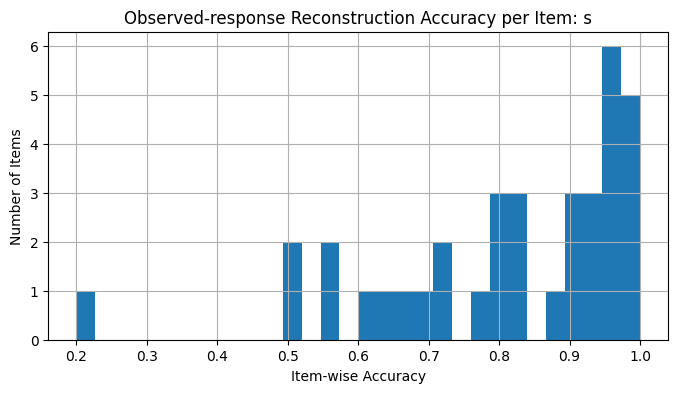

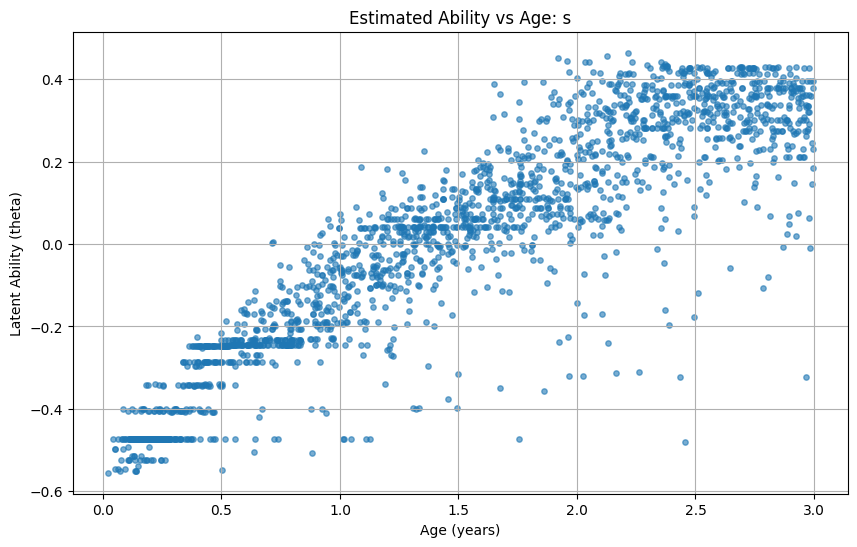


=== Running fm | age > 0 days ===
Selected 42 columns
Train size: 1947, Test size: 20
Items: 42
Age normalization mean: 549.53, std: 311.63
Epoch 001 | Total Loss: 47.11 | Recon: 46.89 | KL: 0.22 | Age monitor: 59.81
Epoch 002 | Total Loss: 45.95 | Recon: 45.70 | KL: 0.26 | Age monitor: 59.56
Epoch 003 | Total Loss: 44.89 | Recon: 44.56 | KL: 0.33 | Age monitor: 59.26
Epoch 004 | Total Loss: 43.88 | Recon: 43.45 | KL: 0.42 | Age monitor: 59.00
Epoch 005 | Total Loss: 42.91 | Recon: 42.38 | KL: 0.53 | Age monitor: 58.74
Epoch 006 | Total Loss: 41.97 | Recon: 41.33 | KL: 0.63 | Age monitor: 58.50
Epoch 007 | Total Loss: 41.06 | Recon: 40.31 | KL: 0.75 | Age monitor: 58.23
Epoch 008 | Total Loss: 40.18 | Recon: 39.31 | KL: 0.87 | Age monitor: 58.04
Epoch 009 | Total Loss: 39.36 | Recon: 38.38 | KL: 0.98 | Age monitor: 57.80
Epoch 010 | Total Loss: 38.56 | Recon: 37.47 | KL: 1.09 | Age monitor: 57.55
Epoch 011 | Total Loss: 37.81 | Recon: 36.61 | KL: 1.20 | Age monitor: 57.32
Epoch 012 | 

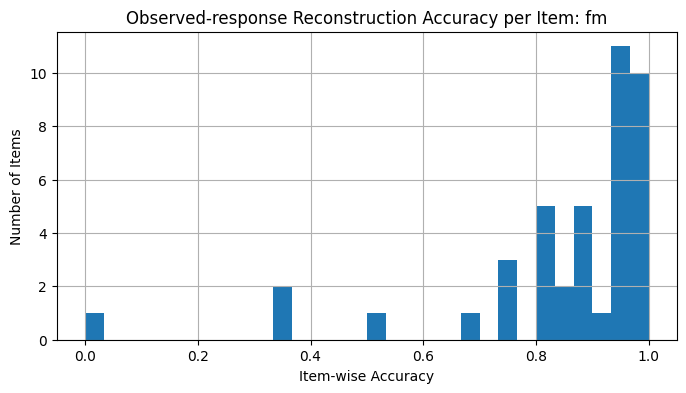

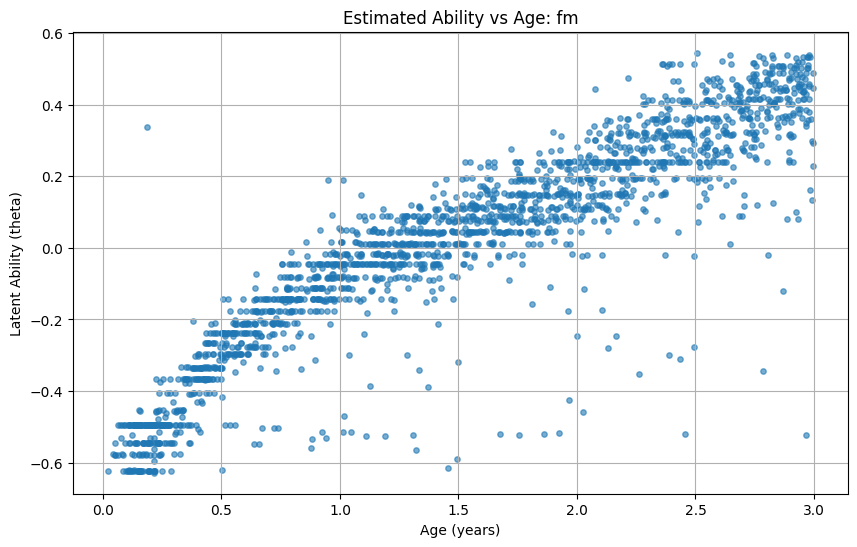


=== Running gm | age > 0 days ===
Selected 39 columns
Train size: 1947, Test size: 20
Items: 39
Age normalization mean: 549.53, std: 311.63
Epoch 001 | Total Loss: 52.73 | Recon: 52.48 | KL: 0.24 | Age monitor: 64.16
Epoch 002 | Total Loss: 51.24 | Recon: 51.03 | KL: 0.21 | Age monitor: 63.15
Epoch 003 | Total Loss: 49.91 | Recon: 49.58 | KL: 0.32 | Age monitor: 62.35
Epoch 004 | Total Loss: 48.60 | Recon: 48.14 | KL: 0.45 | Age monitor: 61.49
Epoch 005 | Total Loss: 47.35 | Recon: 46.75 | KL: 0.60 | Age monitor: 60.69
Epoch 006 | Total Loss: 46.12 | Recon: 45.36 | KL: 0.76 | Age monitor: 59.79
Epoch 007 | Total Loss: 44.92 | Recon: 43.99 | KL: 0.93 | Age monitor: 59.10
Epoch 008 | Total Loss: 43.77 | Recon: 42.68 | KL: 1.09 | Age monitor: 58.37
Epoch 009 | Total Loss: 42.67 | Recon: 41.41 | KL: 1.26 | Age monitor: 57.68
Epoch 010 | Total Loss: 41.61 | Recon: 40.19 | KL: 1.42 | Age monitor: 57.16
Epoch 011 | Total Loss: 40.61 | Recon: 39.08 | KL: 1.54 | Age monitor: 56.70
Epoch 012 | 

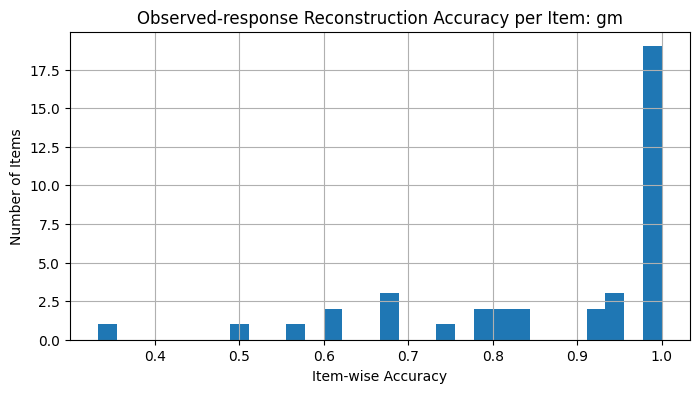

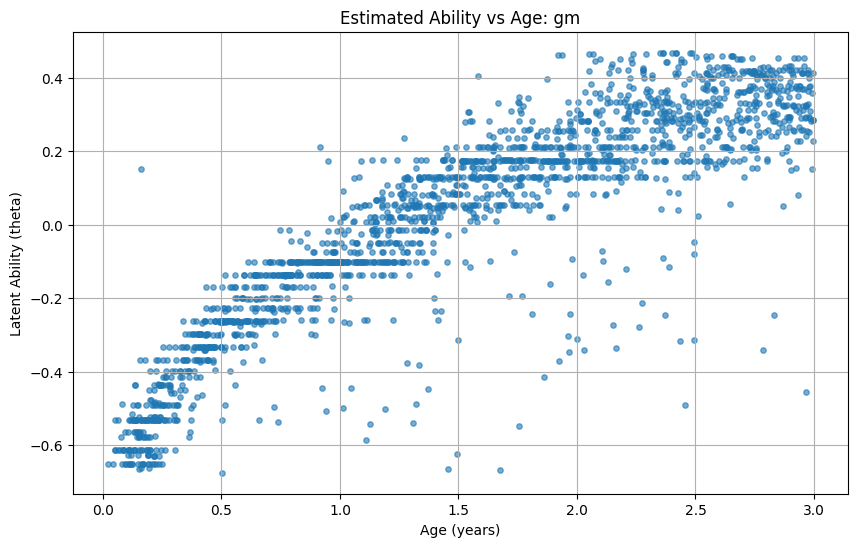


=== Running l | age > 0 days ===
Selected 40 columns
Train size: 1947, Test size: 20
Items: 40
Age normalization mean: 549.53, std: 311.63
Epoch 001 | Total Loss: 44.77 | Recon: 44.50 | KL: 0.27 | Age monitor: 95.66
Epoch 002 | Total Loss: 43.56 | Recon: 43.46 | KL: 0.10 | Age monitor: 95.64
Epoch 003 | Total Loss: 42.72 | Recon: 42.58 | KL: 0.14 | Age monitor: 95.75
Epoch 004 | Total Loss: 41.94 | Recon: 41.76 | KL: 0.18 | Age monitor: 95.77
Epoch 005 | Total Loss: 41.19 | Recon: 40.98 | KL: 0.21 | Age monitor: 95.68
Epoch 006 | Total Loss: 40.49 | Recon: 40.24 | KL: 0.25 | Age monitor: 95.82
Epoch 007 | Total Loss: 39.81 | Recon: 39.52 | KL: 0.29 | Age monitor: 95.88
Epoch 008 | Total Loss: 39.16 | Recon: 38.82 | KL: 0.35 | Age monitor: 96.07
Epoch 009 | Total Loss: 38.53 | Recon: 38.12 | KL: 0.41 | Age monitor: 96.10
Epoch 010 | Total Loss: 37.93 | Recon: 37.45 | KL: 0.49 | Age monitor: 96.24
Epoch 011 | Total Loss: 37.35 | Recon: 36.79 | KL: 0.56 | Age monitor: 96.30
Epoch 012 | T

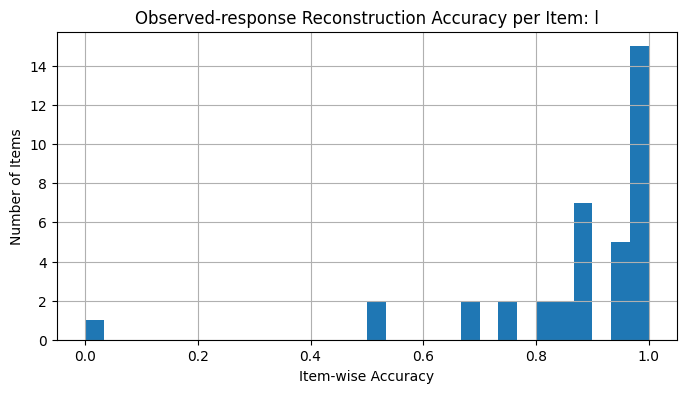

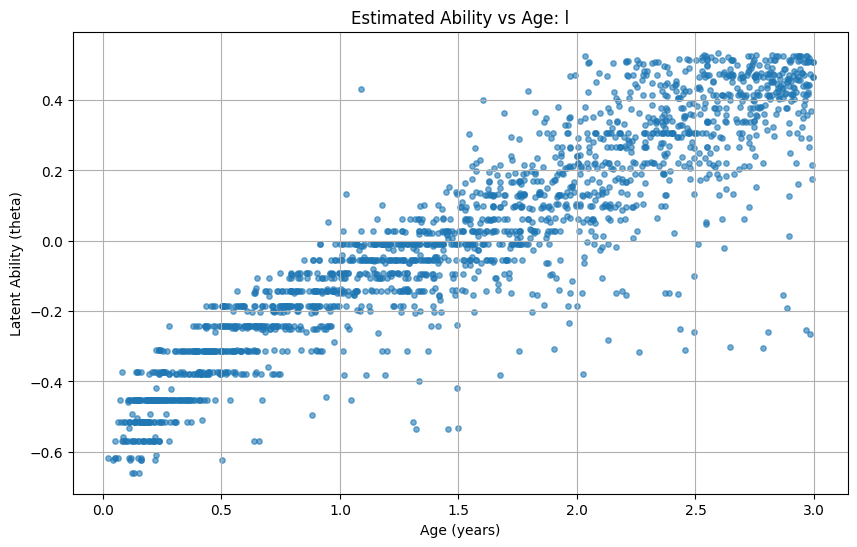


=== Running tot | age > 0 days ===
Selected 157 columns
Train size: 1947, Test size: 20
Items: 157
Age normalization mean: 549.53, std: 311.63
Epoch 001 | Total Loss: 52.76 | Recon: 52.65 | KL: 0.11 | Age monitor: 118.77
Epoch 002 | Total Loss: 51.51 | Recon: 51.47 | KL: 0.04 | Age monitor: 118.11
Epoch 003 | Total Loss: 50.37 | Recon: 50.30 | KL: 0.07 | Age monitor: 116.72
Epoch 004 | Total Loss: 49.26 | Recon: 49.12 | KL: 0.14 | Age monitor: 115.15
Epoch 005 | Total Loss: 48.16 | Recon: 47.93 | KL: 0.22 | Age monitor: 113.37
Epoch 006 | Total Loss: 47.07 | Recon: 46.73 | KL: 0.33 | Age monitor: 111.97
Epoch 007 | Total Loss: 46.04 | Recon: 45.59 | KL: 0.45 | Age monitor: 110.31
Epoch 008 | Total Loss: 45.02 | Recon: 44.43 | KL: 0.59 | Age monitor: 108.98
Epoch 009 | Total Loss: 44.03 | Recon: 43.31 | KL: 0.72 | Age monitor: 107.75
Epoch 010 | Total Loss: 43.09 | Recon: 42.24 | KL: 0.85 | Age monitor: 106.65
Epoch 011 | Total Loss: 42.21 | Recon: 41.23 | KL: 0.98 | Age monitor: 105.6

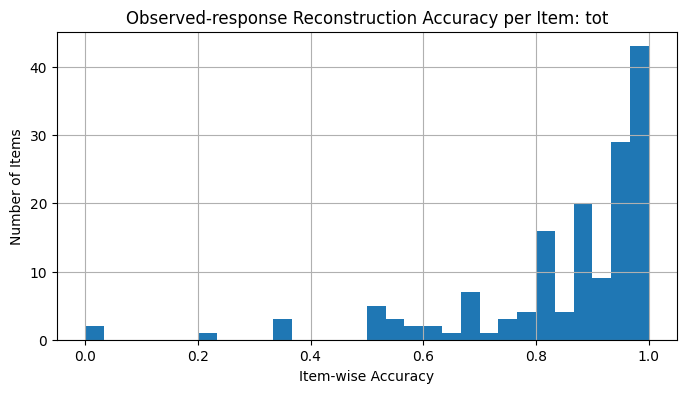

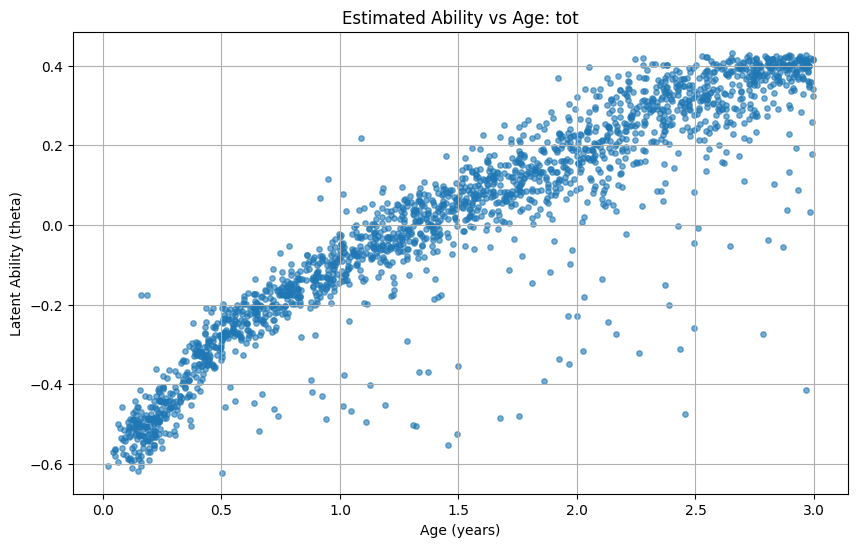

,run_key,output_path,num_items,train_size,test_size,avg_loss,accuracy
0,s,age_s_Deep_ability_0.csv,36,1947,20,0.314874,0.862579
1,fm,age_fm_Deep_ability_0.csv,42,1947,20,0.264530,0.880998
2,gm,age_gm_Deep_ability_0.csv,39,1947,20,0.239875,0.922156
3,l,age_l_Deep_ability_0.csv,40,1947,20,0.236529,0.914216
4,tot,age_tot_Deep_ability_0.csv,157,1947,20,0.278790,0.891224


In [34]:
raw_mdat_data = pd.read_csv(DATA_PATH)

run_outputs = {}
run_summaries = []

for run_key, config in SCORING_RUNS.items():
    run_result = train_and_score_configuration(
        raw_mdat_data,
        run_key,
        config,
        age_min_days=AGE_MIN_DAYS,
        show_plots=SHOW_PLOTS,
    )
    run_outputs[run_key] = run_result
    run_summaries.append(
        {
            "run_key": run_result["run_key"],
            "output_path": run_result["output_path"],
            "num_items": run_result["num_items"],
            "train_size": run_result["train_size"],
            "test_size": run_result["test_size"],
            "avg_loss": run_result["avg_loss"],
            "accuracy": run_result["accuracy"],
        }
    )

run_summary_df = pd.DataFrame(run_summaries)
run_summary_df


In [35]:
combined_scores, combined_output_path = combine_scoring_outputs(
    run_outputs,
    age_min_days=AGE_MIN_DAYS,
)

combined_scores.head()


Saved mdat_Deep_abilities_0.csv


,child_ids,Age,s,fm,gm,l,tot
0,IN-0007-BL,626.0,0.017949,-0.090522,0.207363,-0.092326,0.004537
1,IN-0012-BL,172.0,-0.474150,-0.333629,-0.395101,-0.259772,-0.357846
2,IN-0019-BL,572.0,0.178474,-0.026157,0.128403,-0.021597,0.066994
3,IN-0025-BL,490.0,0.083101,-0.059918,0.175785,0.052709,0.055801
4,IN-0030-BL,498.0,-0.188029,-0.151718,-0.014262,-0.097377,-0.112248


In [36]:
generated_files = pd.DataFrame(
    {
        "run_key": list(run_summary_df["run_key"]) + ["combined"],
        "output_path": list(run_summary_df["output_path"]) + [combined_output_path],
    }
)

generated_files


,run_key,output_path
0,s,age_s_Deep_ability_0.csv
1,fm,age_fm_Deep_ability_0.csv
2,gm,age_gm_Deep_ability_0.csv
3,l,age_l_Deep_ability_0.csv
4,tot,age_tot_Deep_ability_0.csv
5,combined,mdat_Deep_abilities_0.csv
